In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("tested.csv")

In [6]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [7]:
x = df[["Pclass","Sex","Age"]]
y = df.Survived

In [8]:
#to check whetther the x data is clean or not

In [9]:
x.isnull().sum()

Pclass     0
Sex        0
Age       86
dtype: int64

In [19]:
#filling the null values with mean values
x.Age.fillna(x.Age.mean(),inplace=True)

In [18]:
import warnings
warnings.filterwarnings("ignore")
x.isnull().sum()

Pclass    0
Sex       0
Age       0
dtype: int64

In [17]:
x

,Pclass,Sex,Age
0,3,male,34.50000
1,3,female,47.00000
2,2,male,62.00000
3,3,male,27.00000
4,3,female,22.00000
...,...,...,...
413,3,male,30.27259
414,1,female,39.00000
415,3,male,38.50000
416,3,male,30.27259


In [22]:
from sklearn.model_selection import train_test_split

In [81]:
train_x,test_x,train_y,test_y = train_test_split(x,y,test_size = 0.9)

In [77]:
train_x

,Pclass,Age,Gender
381,3,26.00000,1
225,3,30.27259,0
181,1,37.00000,1
96,1,76.00000,0
301,2,30.27259,1
...,...,...,...
205,1,30.27259,1
21,3,9.00000,1
325,3,23.00000,1
41,1,30.27259,1


In [82]:
print(len(train_x))
print(len(train_y))
print(len(test_x))
print(len(test_y))

41
41
377
377


In [44]:
from sklearn.linear_model import LogisticRegression

In [45]:
model = LogisticRegression()

In [46]:
#to convert string data to int data
from sklearn.preprocessing import LabelEncoder
l = LabelEncoder()
gen = l.fit_transform(x.Sex)

AttributeError: 'DataFrame' object has no attribute 'Sex'

In [52]:
x['Gender'] = gen
# x.drop('Sex',axis=1,inplace=True)

In [83]:
x

,Pclass,Age,Gender
0,3,34.50000,1
1,3,47.00000,0
2,2,62.00000,1
3,3,27.00000,1
4,3,22.00000,0
...,...,...,...
413,3,30.27259,1
414,1,39.00000,0
415,3,38.50000,1
416,3,30.27259,1


In [84]:
model.fit(train_x,train_y)

LogisticRegression()

In [85]:
model.score(test_x,test_y)

1.0

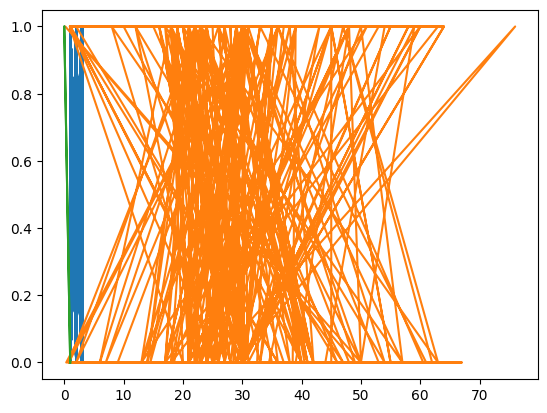

In [88]:
import matplotlib.pyplot as plt
plt.plot(x,y)

In [98]:
model.predict([[1,25,0]])

array([1], dtype=int64)